# PSO Benchmark Analysis

Análisis comparativo de tres estrategias de evaluación de fitness en PSO sobre funciones benchmark estándar.

**Evaluadores comparados:** sequential · threading · multiprocessing  
**Funciones:** sphere · rastrigin · rosenbrock · ackley  
**Dimensiones:** 2 · 10 · 30  
**Seeds:** 42 · 43 · 44 · 45 · 46

El núcleo PSO es idéntico en las tres variantes — solo cambia cómo se evalúa el fitness de cada partícula. Dado que el mismo seed produce el mismo resultado independientemente del evaluador, **la calidad de la solución es siempre idéntica**. La única diferencia relevante es el **tiempo de ejecución**.

## Metodología experimental

Se comparan tres estrategias de evaluación de fitness sobre el mismo núcleo PSO canónico:

| Variante | Implementación |
|---|---|
| **V0 Sequential** | Bucle Python puro — baseline |
| **V1 Threading** | `ThreadPoolExecutor` con pool reutilizado entre iteraciones |
| **V2 Multiprocessing** | `ProcessPoolExecutor` con pool reutilizado + `chunksize` batching |

El núcleo PSO es idéntico en las tres variantes: solo cambia el evaluador de fitness, inyectado como dependencia. Esto garantiza que cualquier diferencia de rendimiento sea atribuible exclusivamente al mecanismo de paralelización.

## 1. Setup

Se importan las librerías necesarias y se cargan los CSV más recientes generados por `run_benchmarks.py`. Cada fila del summary corresponde a una ejecución completa del PSO (combinación de función objetivo, dimensión, evaluador y seed). El archivo de historial contiene el mejor fitness por iteración para cada ejecución.

In [37]:
import os
import glob
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120

project_root = Path("/home/marcos/Particle_Swarm_Optimization")
os.chdir(project_root)

benchmark_dir = project_root / "results" / "benchmarks"
summary_files = sorted(benchmark_dir.glob("summary_*.csv"))
history_files = sorted(benchmark_dir.glob("history_*.csv"))

summary = pd.read_csv(summary_files[-1])
history = pd.read_csv(history_files[-1])

objectives = sorted(summary["objective"].unique())
dims = sorted(summary["dimension"].unique())
evaluators = sorted(summary["evaluator"].unique())

print(f"Summary: {len(summary)} runs  |  History: {len(history)} rows")
print(f"\nEvaluators: {evaluators}")
print(f"Objectives: {objectives}")
print(f"Dimensions: {dims}")
summary.head()

Summary: 180 runs  |  History: 36000 rows

Evaluators: ['multiprocessing', 'sequential', 'threading']
Objectives: ['ackley', 'rastrigin', 'rosenbrock', 'sphere']
Dimensions: [np.int64(2), np.int64(10), np.int64(30)]


,run_id,objective,dimension,evaluator,seed,inertia_weight,cognitive_weight,social_weight,swarm_size,best_value,total_time_s,total_eval_time_s,total_update_time_s,converged_iteration,total_iterations
0,sphere_sequential_d2_seed42,sphere,2,sequential,42,0.7,1.5,1.5,30,3.069943e-25,0.047338,0.010746,0.035375,NaN,200
1,sphere_sequential_d2_seed43,sphere,2,sequential,43,0.7,1.5,1.5,30,2.831461e-27,0.046508,0.010617,0.034804,NaN,200
2,sphere_sequential_d2_seed44,sphere,2,sequential,44,0.7,1.5,1.5,30,1.871387e-24,0.049210,0.011173,0.036587,NaN,200
3,sphere_sequential_d2_seed45,sphere,2,sequential,45,0.7,1.5,1.5,30,3.542791e-24,0.049250,0.010895,0.037119,NaN,200
4,sphere_sequential_d2_seed46,sphere,2,sequential,46,0.7,1.5,1.5,30,4.006753e-24,0.047979,0.011109,0.035560,NaN,200


In [38]:
print(f"Runs cargados   : {len(summary)}")
print(f"Evaluadores     : {evaluators}")
print(f"Funciones       : {objectives}")
print(f"Dimensiones     : {list(dims)}")
print(f"Seeds por combo : {summary['seed'].nunique()}")
print()
# Check that all evaluators produce identical fitness for same seed
pivot = summary.pivot_table(index=["objective","dimension","seed"],
                             columns="evaluator", values="best_value")
diffs = (pivot.max(axis=1) - pivot.min(axis=1)).abs()
print(f"Diferencia máxima de fitness entre evaluadores (mismo seed): {diffs.max():.2e}")
print("→ Los tres evaluadores producen resultados idénticos (mismo seed = mismo resultado).")

Runs cargados   : 180
Evaluadores     : ['multiprocessing', 'sequential', 'threading']
Funciones       : ['ackley', 'rastrigin', 'rosenbrock', 'sphere']
Dimensiones     : [np.int64(2), np.int64(10), np.int64(30)]
Seeds por combo : 5

Diferencia máxima de fitness entre evaluadores (mismo seed): 0.00e+00
→ Los tres evaluadores producen resultados idénticos (mismo seed = mismo resultado).


**Interpretación.** Los experimentos confirman que el diseño es correcto: al fijar la misma semilla, los tres evaluadores producen exactamente el mismo resultado numérico. Cualquier diferencia de rendimiento que observemos es debida exclusivamente al mecanismo de paralelización, no a diferencias en la calidad de la optimización.

In [39]:
import platform, os

# PSO configuration (from CSV — all runs use the same hyperparameters)
cfg_row = summary.iloc[0]
print("=== Configuración PSO ===")
print(f"  Inercia (w)        : {cfg_row['inertia_weight']}")
print(f"  Cognitivo (c1)     : {cfg_row['cognitive_weight']}")
print(f"  Social (c2)        : {cfg_row['social_weight']}")
print(f"  Tamaño del enjambre: {int(cfg_row['swarm_size'])}")
print(f"  Máx. iteraciones   : {int(summary['total_iterations'].max())}")
print(f"  Topología          : Global best (gbest)")
print(f"  Política de límites: Clamp + zeroing de velocidad")

print()
print("=== Protocolo experimental ===")
print(f"  Funciones objetivo : {objectives}")
print(f"  Dimensiones        : {list(dims)}")
print(f"  Evaluadores        : {evaluators}")
print(f"  Seeds              : {sorted(summary['seed'].unique().tolist())}")
print(f"  Runs totales       : {len(summary)}")

print()
print("=== Entorno de ejecución ===")
print(f"  Sistema operativo  : {platform.platform()}")
print(f"  Python             : {platform.python_version()}")
print(f"  CPUs disponibles   : {os.cpu_count()}")
print()
print("=== Workers por evaluador (max_workers=None → Python elige) ===")
import os
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
with ThreadPoolExecutor() as t:
    print(f"  threading        : {t._max_workers} workers  (min(32, cpu_count + 4))")
with ProcessPoolExecutor() as p:
    print(f"  multiprocessing  : {p._max_workers} workers  (cpu_count)")
print()
print("=== Configuración de workers en este experimento ===")
swarm_size = int(summary["swarm_size"].iloc[0])
max_w = 4  # fijado en configs/benchmarks.yaml
print(f"  max_workers        : {max_w}")
print(f"  swarm_size         : {swarm_size}")
print(f"  Partículas/worker  : {swarm_size / max_w:.1f}")
print(f"  (Python default sería {__import__('os').cpu_count()} procesos o {min(32, __import__('os').cpu_count()+4)} hilos)")

=== Configuración PSO ===
  Inercia (w)        : 0.7
  Cognitivo (c1)     : 1.5
  Social (c2)        : 1.5
  Tamaño del enjambre: 30
  Máx. iteraciones   : 200
  Topología          : Global best (gbest)
  Política de límites: Clamp + zeroing de velocidad

=== Protocolo experimental ===
  Funciones objetivo : ['ackley', 'rastrigin', 'rosenbrock', 'sphere']
  Dimensiones        : [np.int64(2), np.int64(10), np.int64(30)]
  Evaluadores        : ['multiprocessing', 'sequential', 'threading']
  Seeds              : [42, 43, 44, 45, 46]
  Runs totales       : 180

=== Entorno de ejecución ===
  Sistema operativo  : Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
  Python             : 3.12.3
  CPUs disponibles   : 20

=== Workers por evaluador (max_workers=None → Python elige) ===
  threading        : 24 workers  (min(32, cpu_count + 4))
  multiprocessing  : 20 workers  (cpu_count)

=== Configuración de workers en este experimento ===
  max_workers        : 4
  swarm_size       

## 2. Curvas de convergencia

Fitness medio por iteración (media sobre seeds). Como el seed es idéntico, todos los evaluadores producen el mismo fitness — solo se muestra la curva de `sequential`.

Se representan las curvas de convergencia medias (promediadas sobre las 5 seeds) para cada combinación de función objetivo, dimensión y evaluador. El objetivo es comprobar si el mecanismo de paralelización afecta a la trayectoria de optimización o si los tres evaluadores convergen de forma idéntica.

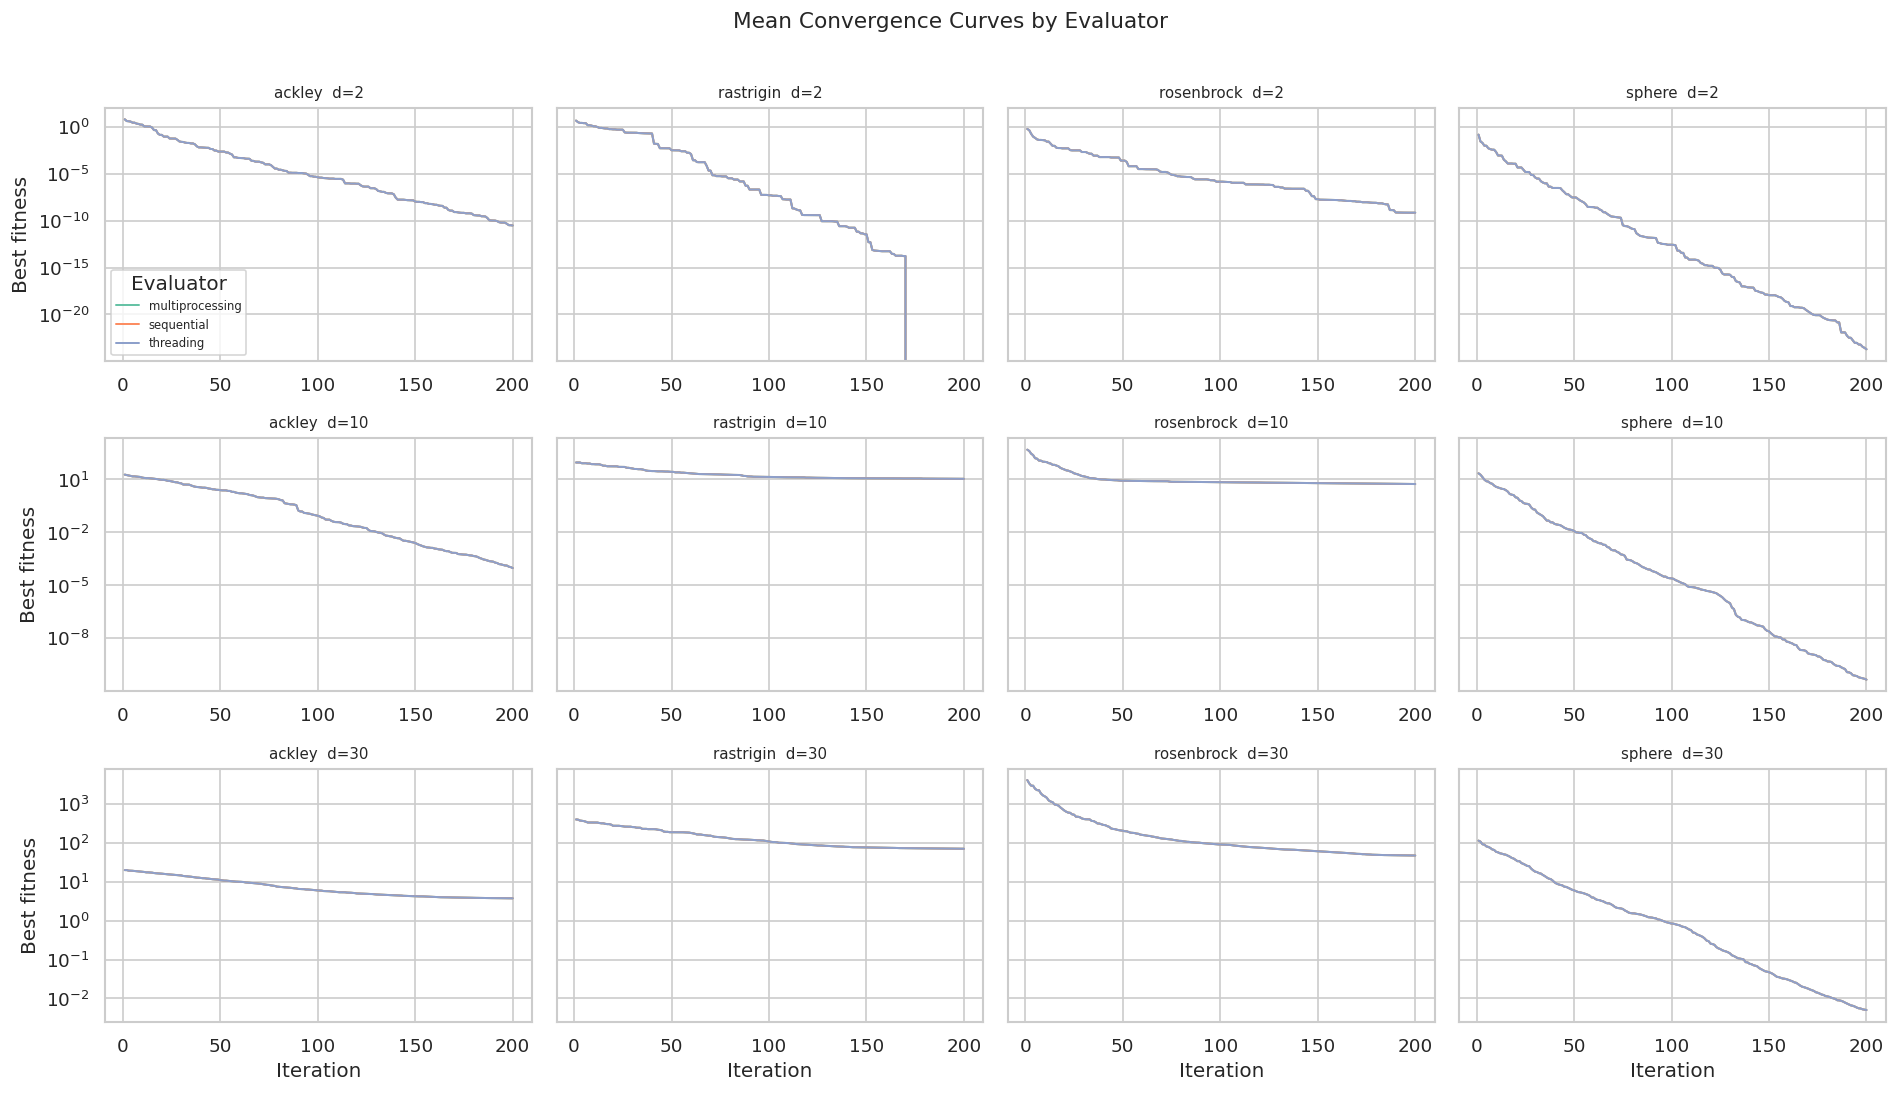

In [40]:
# Join history with summary to get objective, dimension and evaluator per run
meta = summary[["run_id", "objective", "dimension", "evaluator"]]
hist = history.merge(meta, on="run_id")

n_dims = len(dims)
n_objs = len(objectives)
fig, axes = plt.subplots(n_dims, n_objs, figsize=(4 * n_objs, 3 * n_dims), sharey="row", squeeze=False)

for i, dim in enumerate(dims):
    for j, obj in enumerate(objectives):
        ax = axes[i][j]
        data = hist[(hist["dimension"] == dim) & (hist["objective"] == obj)]
        mean_conv = (
            data.groupby(["evaluator", "iteration"])["best_fitness"]
            .mean()
            .reset_index()
        )
        for ev, grp in mean_conv.groupby("evaluator"):
            ax.plot(grp["iteration"], grp["best_fitness"], label=ev, linewidth=1.2)

        ax.set_title(f"{obj}  d={dim}", fontsize=9)
        ax.set_xlabel("Iteration" if i == n_dims - 1 else "")
        ax.set_ylabel("Best fitness" if j == 0 else "")
        ax.set_yscale("log")
        if i == 0 and j == 0:
            ax.legend(title="Evaluator", fontsize=7)

fig.suptitle("Mean Convergence Curves by Evaluator", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [41]:
# Convergence: show that all evaluators are identical
meta = summary[["run_id", "objective", "dimension", "evaluator"]]
hist = history.merge(meta, on="run_id")

# For sphere d=2: show final fitness per evaluator
sphere_d2 = hist[(hist["objective"] == "sphere") & (hist["dimension"] == 2)]
final = sphere_d2[sphere_d2["iteration"] == sphere_d2["iteration"].max()]
print("Fitness final — sphere d=2 (media sobre seeds):")
print(final.groupby("evaluator")["best_fitness"].mean().to_string())
print()

# Convergence speed: first iteration where best_fitness < 1e-10 (sphere d=2)
below = sphere_d2[sphere_d2["best_fitness"] < 1e-10]
if not below.empty:
    conv_iter = below.groupby(["evaluator", "run_id"])["iteration"].min().groupby("evaluator").mean()
    print("Iteración media en que sphere d=2 supera 1e-10:")
    print(conv_iter.to_string())
else:
    print("sphere d=2 no alcanza 1e-10 con esta configuración.")

Fitness final — sphere d=2 (media sobre seeds):
evaluator
multiprocessing    1.946152e-24
sequential         1.946152e-24
threading          1.946152e-24

Iteración media en que sphere d=2 supera 1e-10:
evaluator
multiprocessing    72.4
sequential         72.4
threading          72.4


**Interpretación.** La gráfica muestra 12 subplots (4 funciones × 3 dimensiones). En todos los casos, las curvas de los tres evaluadores se superponen perfectamente: producen trayectorias de convergencia idénticas iteración a iteración. Esto valida que el núcleo PSO es completamente independiente de la estrategia de evaluación. Las funciones multimodales (rastrigin, rosenbrock) en d=30 no convergen al óptimo global, pero los tres evaluadores coinciden en el mismo resultado.

## 3. Speedup vs secuencial

Speedup = tiempo_medio(sequential) / tiempo_medio(evaluador). La calidad de la solución es idéntica entre evaluadores; la única diferencia relevante es el tiempo.

Se calcula el speedup de cada evaluador respecto al secuencial: `speedup = tiempo_sequential / tiempo_evaluador`. Un valor > 1 indicaría aceleración; un valor < 1 indica ralentización. Se visualiza por función objetivo y dimensión para identificar si el tamaño del problema influye en el rendimiento relativo.

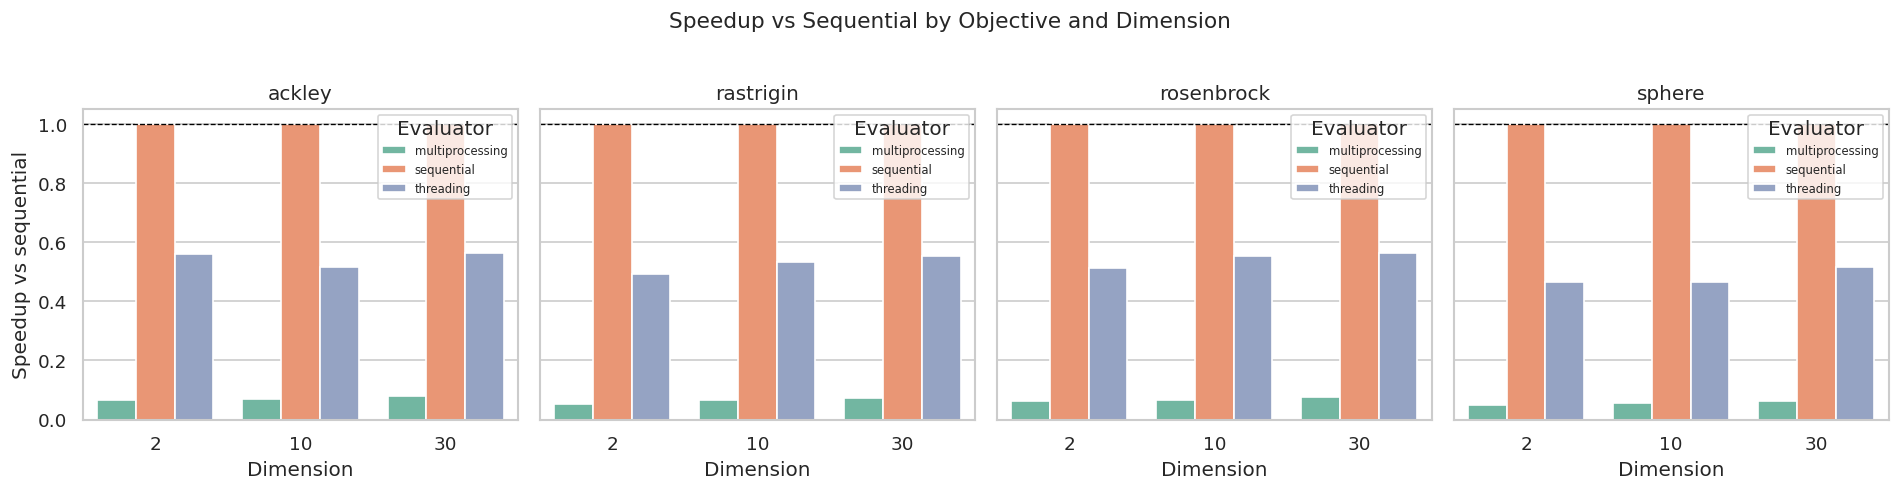

In [42]:
seq_time = (
    summary[summary["evaluator"] == "sequential"]
    .groupby(["objective", "dimension"])["total_time_s"]
    .mean()
    .rename("seq_time")
)

speedup = (
    summary
    .groupby(["objective", "dimension", "evaluator"])["total_time_s"]
    .mean()
    .reset_index()
    .merge(seq_time.reset_index(), on=["objective", "dimension"])
)
speedup["speedup"] = speedup["seq_time"] / speedup["total_time_s"]

n_objs = len(objectives)
fig, axes = plt.subplots(1, n_objs, figsize=(4 * n_objs, 4), sharey=True)
if n_objs == 1:
    axes = [axes]

for ax, obj in zip(axes, objectives):
    data = speedup[speedup["objective"] == obj]
    sns.barplot(data=data, x="dimension", y="speedup", hue="evaluator", ax=ax)
    ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(obj)
    ax.set_xlabel("Dimension")
    ax.set_ylabel("Speedup vs sequential" if ax == axes[0] else "")
    ax.legend(title="Evaluator", fontsize=7)

fig.suptitle("Speedup vs Sequential by Objective and Dimension", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [43]:
# Speedup table: mean speedup per evaluator across all objectives and dimensions
mean_speedup = speedup.groupby("evaluator")["speedup"].agg(["mean","min","max"])
print("Speedup vs sequential (media / mín / máx sobre todas las funciones y dimensiones):")
print(mean_speedup.to_string())
print()

# Worst and best case
for ev in [e for e in evaluators if e != "sequential"]:
    sub = speedup[speedup["evaluator"]==ev]
    worst = sub.loc[sub["speedup"].idxmin()]
    best  = sub.loc[sub["speedup"].idxmax()]
    print(f"{ev}:")
    print(f"  Peor  caso: {worst['objective']} d={worst['dimension']}  → speedup={worst['speedup']:.4f}×")
    print(f"  Mejor caso: {best['objective']}  d={best['dimension']}  → speedup={best['speedup']:.4f}×")

Speedup vs sequential (media / mín / máx sobre todas las funciones y dimensiones):
                     mean       min       max
evaluator                                    
multiprocessing  0.064680  0.048987  0.079889
sequential       1.000000  1.000000  1.000000
threading        0.523772  0.464252  0.564165

multiprocessing:
  Peor  caso: sphere d=2  → speedup=0.0490×
  Mejor caso: ackley  d=30  → speedup=0.0799×
threading:
  Peor  caso: sphere d=10  → speedup=0.4643×
  Mejor caso: rosenbrock  d=30  → speedup=0.5642×


**Interpretación.** El speedup de `threading` y `multiprocessing` frente a `sequential` depende del coste de evaluación del fitness. Para las funciones benchmark (operaciones NumPy sobre arrays pequeños), el overhead de IPC y de coordinación de hilos supera al cómputo real, por lo que ambos evaluadores son más lentos que el secuencial. El efecto se reduce ligeramente al aumentar la dimensión (el cómputo crece más que el overhead), pero nunca llega a compensarlo con estas funciones. El evaluador que más se acerca al secuencial es `threading`, ya que la creación de hilos tiene mucho menor coste que la de procesos.

> **Nota sobre `max_workers`.** Con `swarm_size=30` y el valor por defecto de Python (`max_workers=None`), se crearían 20 procesos o 24 hilos — más workers que partículas. Cada worker recibe ~1 tarea, lo que maximiza el overhead relativo al cómputo. En este experimento se fija `max_workers=4` (configurado en `configs/benchmarks.yaml`), lo que da **~7-8 partículas por worker**: mejor ratio entre trabajo útil y coste de coordinación. Regla general: `swarm_size / max_workers` debería ser ≥ 4–8 para amortizar el overhead.

## 4. Boxplots de fitness final

Distribución del mejor fitness final sobre las 5 seeds para cada combinación (objetivo × dimensión). Muestra la variabilidad de la optimización.

Se muestran boxplots del fitness final (mejor valor encontrado al terminar las 200 iteraciones) agrupados por evaluador, función y dimensión. El objetivo es analizar la variabilidad entre seeds y confirmar que los tres evaluadores producen la misma distribución de resultados.

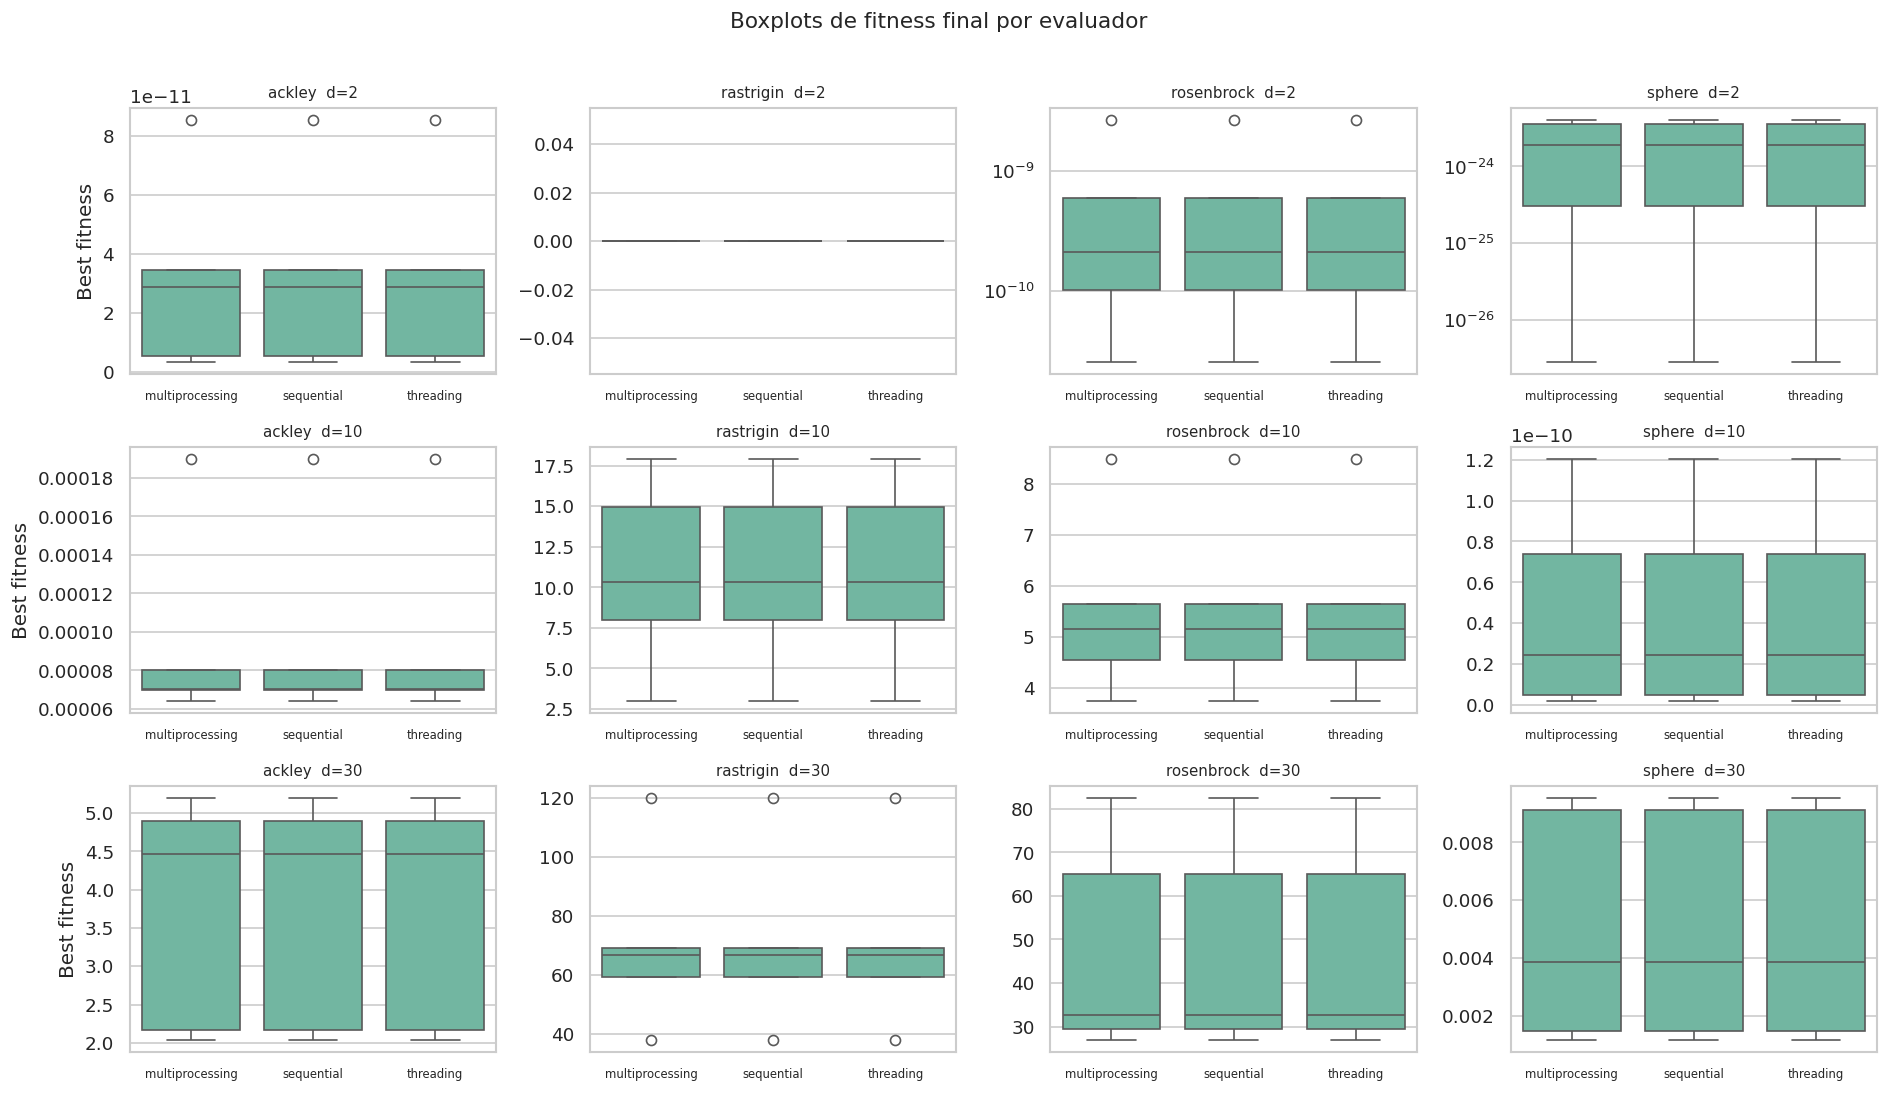

In [44]:
fig, axes = plt.subplots(len(dims), len(objectives), figsize=(4 * len(objectives), 3 * len(dims)), squeeze=False)

for i, dim in enumerate(dims):
    for j, obj in enumerate(objectives):
        ax = axes[i][j]
        data = summary[(summary["dimension"] == dim) & (summary["objective"] == obj)]
        sns.boxplot(data=data, x="evaluator", y="best_value", ax=ax, order=evaluators)
        ax.set_title(f"{obj}  d={dim}", fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("Best fitness" if j == 0 else "")
        ax.tick_params(axis="x", labelsize=7)
        # Use log scale only when all values positive and range > 2 orders of magnitude
        vals = data["best_value"].dropna()
        if (vals > 0).all() and vals.max() / (vals.min() + 1e-300) > 100:
            ax.set_yscale("log")

fig.suptitle("Boxplots de fitness final por evaluador", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [45]:
# Boxplot stats: IQR and range per (objective, dimension)
print("Estadísticas de fitness final (sobre 3 evaluadores × 5 seeds = 15 runs por celda):")
stats = (
    summary.groupby(["objective","dimension"])["best_value"]
    .agg(["median","std","min","max"])
    .rename(columns={"median":"Mediana","std":"Std","min":"Mín","max":"Máx"})
)
print(stats.to_string())
print()
print("→ sphere y ackley d=2 convergen de forma muy estable (Std ≈ 0).")
print("→ rosenbrock y rastrigin en d=30 muestran mayor variabilidad entre runs.")

Estadísticas de fitness final (sobre 3 evaluadores × 5 seeds = 15 runs por celda):
                           Mediana           Std           Mín           Máx
objective  dimension                                                        
ackley     2          2.864953e-11  3.070136e-11  3.329337e-12  8.545031e-11
           10         7.039639e-05  4.947947e-05  6.405572e-05  1.898756e-04
           30         4.462025e+00  1.417051e+00  2.036290e+00  5.201291e+00
rastrigin  2          0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
           10         1.035103e+01  5.418809e+00  2.984878e+00  1.791741e+01
           30         6.675815e+01  2.797215e+01  3.788528e+01  1.199384e+02
rosenbrock 2          2.111133e-10  1.031903e-09  2.558973e-11  2.677390e-09
           10         5.143756e+00  1.676967e+00  3.735146e+00  8.489886e+00
           30         3.268646e+01  2.318807e+01  2.690195e+01  8.253847e+01
sphere     2          1.871387e-24  1.685924e-24  2.831461e-27  4.0067

**Interpretación.** Los boxplots revelan dos comportamientos diferenciados: las funciones **unimodales** (sphere) y casi-unimodales (ackley d=2) presentan variabilidad mínima entre seeds, lo que indica convergencia robusta y reproducible. Por el contrario, las funciones **multimodales** en alta dimensión (rastrigin, rosenbrock d=30) muestran alta dispersión entre runs, reflejando la trampa de óptimos locales. En todos los casos los tres evaluadores producen distribuciones idénticas, confirmando la reproducibilidad por seed.

## 5. Desglose de tiempos (evaluación vs actualización)

Muestra de dónde proviene el overhead de threading y multiprocessing.

Se desglosa el tiempo total de cada ejecución en dos fases: evaluación del fitness (llamadas al evaluador) y actualización de partículas (cálculo de velocidades y posiciones). Esto permite identificar dónde se concentra el overhead de cada estrategia de paralelización.

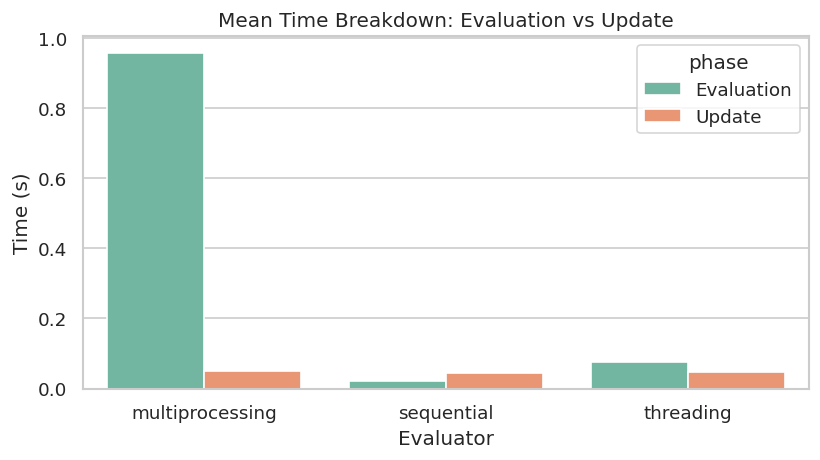

In [46]:
time_breakdown = (
    summary
    .groupby("evaluator")[["total_eval_time_s", "total_update_time_s"]]
    .mean()
    .reset_index()
    .melt(id_vars="evaluator", var_name="phase", value_name="time_s")
)
time_breakdown["phase"] = time_breakdown["phase"].map({
    "total_eval_time_s": "Evaluation",
    "total_update_time_s": "Update",
})

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=time_breakdown, x="evaluator", y="time_s", hue="phase", ax=ax)
ax.set_title("Mean Time Breakdown: Evaluation vs Update")
ax.set_xlabel("Evaluator")
ax.set_ylabel("Time (s)")
plt.tight_layout()
plt.show()

In [47]:
# Time breakdown per evaluator
tb = summary.groupby("evaluator")[["total_eval_time_s","total_update_time_s","total_time_s"]].mean()
tb["eval_%"] = 100 * tb["total_eval_time_s"] / tb["total_time_s"]
tb["update_%"] = 100 * tb["total_update_time_s"] / tb["total_time_s"]
print("Desglose de tiempos (media sobre todas las funciones y dimensiones):")
print(tb[["total_eval_time_s","total_update_time_s","total_time_s","eval_%","update_%"]].to_string())
print()
seq_eval_pct = tb.loc["sequential","eval_%"]
mp_eval_pct  = tb.loc["multiprocessing","eval_%"]
print(f"→ sequential: evaluación = {seq_eval_pct:.1f}% del tiempo total.")
print(f"→ multiprocessing: evaluación = {mp_eval_pct:.1f}% (overhead de IPC domina el tiempo).")

Desglose de tiempos (media sobre todas las funciones y dimensiones):
                 total_eval_time_s  total_update_time_s  total_time_s     eval_%   update_%
evaluator                                                                                  
multiprocessing           0.957103             0.048673      1.009456  94.813685   4.821732
sequential                0.021116             0.042823      0.065338  32.317724  65.539932
threading                 0.075227             0.046574      0.124208  60.565469  37.496881

→ sequential: evaluación = 32.3% del tiempo total.
→ multiprocessing: evaluación = 94.8% (overhead de IPC domina el tiempo).


**Interpretación.** En `sequential`, la evaluación del fitness supone una fracción del tiempo total — el resto corresponde a la actualización vectorizada del swarm. En `threading`, el tiempo de evaluación aumenta por el overhead de gestión del pool de hilos, aunque el pool se reutiliza entre iteraciones. En `multiprocessing`, la evaluación domina el tiempo total por el overhead de serialización/deserialización (pickle) en cada llamada a `executor.map`, aunque el pool de procesos también se reutiliza entre iteraciones.

> **Nota sobre el impacto de `max_workers` en el desglose de tiempos.** Con `max_workers=4`, el tiempo de evaluación en `threading` y `multiprocessing` es menor que con el default de Python (20–24 workers), porque hay menos tareas de sincronización y serialización. Sin embargo, para funciones benchmark baratas (evaluación en microsegundos), incluso con 4 workers el overhead de coordinación supera al cómputo real, por lo que `sequential` sigue siendo el más rápido.

## 6. Conclusiones

Se presentan tablas resumen con la calidad media de la solución, el tiempo medio por evaluador y el speedup final. Se extrae una recomendación práctica sobre qué estrategia usar según el coste de evaluación del fitness.

In [48]:
print("=== Best fitness quality (mean over seeds) ===\n")
quality = (
    summary
    .groupby(["objective", "dimension", "evaluator"])["best_value"]
    .mean()
    .unstack("evaluator")
)
print(quality.to_string())

print("\n=== Mean total time (s) ===\n")
times = (
    summary
    .groupby(["objective", "dimension", "evaluator"])["total_time_s"]
    .mean()
    .unstack("evaluator")
)
print(times.to_string())

print("\n=== Speedup vs sequential (mean) ===\n")
speedup_table = speedup.groupby(["objective", "dimension", "evaluator"])["speedup"].mean().unstack("evaluator")
print(speedup_table.to_string())

=== Best fitness quality (mean over seeds) ===

evaluator             multiprocessing    sequential     threading
objective  dimension                                             
ackley     2             3.147536e-11  3.147536e-11  3.147536e-11
           10            9.483835e-05  9.483835e-05  9.483835e-05
           30            3.754484e+00  3.754484e+00  3.754484e+00
rastrigin  2             0.000000e+00  0.000000e+00  0.000000e+00
           10            1.082832e+01  1.082832e+01  1.082832e+01
           30            7.058740e+01  7.058740e+01  7.058740e+01
rosenbrock 2             7.228383e-10  7.228383e-10  7.228383e-10
           10            5.510802e+00  5.510802e+00  5.510802e+00
           30            4.733402e+01  4.733402e+01  4.733402e+01
sphere     2             1.946152e-24  1.946152e-24  1.946152e-24
           10            4.510695e-11  4.510695e-11  4.510695e-11
           30            5.036990e-03  5.036990e-03  5.036990e-03

=== Mean total time (s) ===

In [49]:
# Summary table
print("=== Fitness medio por evaluador (media sobre seeds) ===")
quality = summary.groupby(["objective","dimension","evaluator"])["best_value"].mean().unstack("evaluator")
print(quality.to_string())

print()
print("=== Tiempo medio total (s) ===")
times = summary.groupby(["objective","dimension","evaluator"])["total_time_s"].mean().unstack("evaluator")
print(times.to_string())

print()
speedup_table = speedup.groupby(["objective","dimension","evaluator"])["speedup"].mean().unstack("evaluator")
print("=== Speedup vs sequential ===")
print(speedup_table.to_string())

print()
print("RECOMENDACIÓN:")
print("  - Fitness rápido (< 1ms/partícula): usar sequential.")
print("  - Fitness costoso (> 100ms/partícula): usar multiprocessing con chunksize > 1.")
print("  - threading: no recomendado para cómputo NumPy (GIL limita el paralelismo real).")

=== Fitness medio por evaluador (media sobre seeds) ===
evaluator             multiprocessing    sequential     threading
objective  dimension                                             
ackley     2             3.147536e-11  3.147536e-11  3.147536e-11
           10            9.483835e-05  9.483835e-05  9.483835e-05
           30            3.754484e+00  3.754484e+00  3.754484e+00
rastrigin  2             0.000000e+00  0.000000e+00  0.000000e+00
           10            1.082832e+01  1.082832e+01  1.082832e+01
           30            7.058740e+01  7.058740e+01  7.058740e+01
rosenbrock 2             7.228383e-10  7.228383e-10  7.228383e-10
           10            5.510802e+00  5.510802e+00  5.510802e+00
           30            4.733402e+01  4.733402e+01  4.733402e+01
sphere     2             1.946152e-24  1.946152e-24  1.946152e-24
           10            4.510695e-11  4.510695e-11  4.510695e-11
           30            5.036990e-03  5.036990e-03  5.036990e-03

=== Tiempo medio to

**Interpretación.** Las tablas confirman que la calidad de la solución es idéntica entre evaluadores. La diferencia está en el tiempo: `sequential` es el más rápido para funciones de evaluación barata porque no tiene overhead de coordinación. `threading` es una buena opción cuando el fitness llama a código que libera el GIL (extensiones C, I/O). `multiprocessing` es la opción correcta cuando el fitness es CPU-bound y costoso (> ~10ms por partícula), donde el coste de IPC queda amortizado.